## 1. Introduzione al Model Context Protocol (MCP)

https://modelcontextprotocol.io/docs/getting-started/intro

Il Model Context Protocol (MCP) è un protocollo open-source sviluppato da Anthropic per standardizzare il modo in cui le applicazioni AI si connettono a fonti di dati e strumenti esterni.

### Cos'è MCP?

MCP risolve un problema fondamentale nell'ecosistema dell'intelligenza artificiale: la frammentazione delle integrazioni. 

Invece di dover costruire integrazioni personalizzate per ogni combinazione di applicazione AI e fonte di dati, MCP fornisce un protocollo universale che permette ai modelli linguistici di interagire con qualsiasi sistema compatibile.

### Come funziona?
MCP segue un'architettura client-server:

- I server MCP espongono risorse (dati), strumenti (azioni) e prompt
- I client MCP (come Claude Desktop o altre applicazioni AI) si connettono a questi server
- Gli host mantengono connessioni persistenti tra client e server

### Vantaggi principali

- Universalità: un'unica integrazione funziona con tutti i client compatibili
- Sicurezza: controllo granulare degli accessi e delle autorizzazioni
- Semplicità: riduce drasticamente la complessità dello sviluppo
- Flessibilità: supporta database, API, file system e molto altro

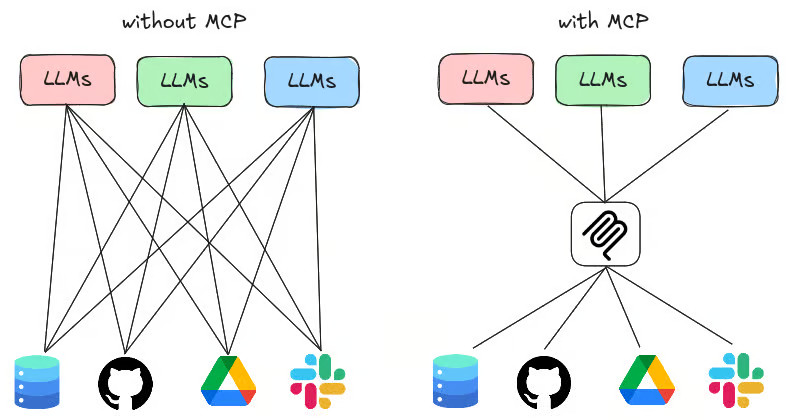

### Architettura di un'architettura MCP

I tre punti fondamentali su cui l'architettura MCP punta:

1. **Tools**

sistema di function calling visto nella lezione precedente

2. **Resources**

novità di MCP,  non solo permette di  chiamare funzioni, ma anche esporre dati che l'LLM può leggere:
```python
# Esponi un file come risorsa
resources = [
    {
        "uri": "file:///docs/manual.pdf",
        "name": "Manuale Utente",
        "description": "Documentazione completa del prodotto",
        "mimeType": "application/pdf"
    }
]
```

3. **Prompts (Template Preconfigurati)**

permettte di costruire prompt template pronti all'uso

```python
prompts = [
    {
        "name": "analyze_bug",
        "description": "Analizza un bug report",
        "arguments": ["bug_id"]
    }
]
```


**Componenti:**

- **MCP Client**: L'applicazione che usa l'LLM 
- **MCP Server**: Il codice Python che espone tools/resources/prompts
- **JSON-RPC**: Protocollo di comunicazione standard (come REST ma per chiamate locali)
- **stdio**: I server comunicano via standard input/output (semplice!)

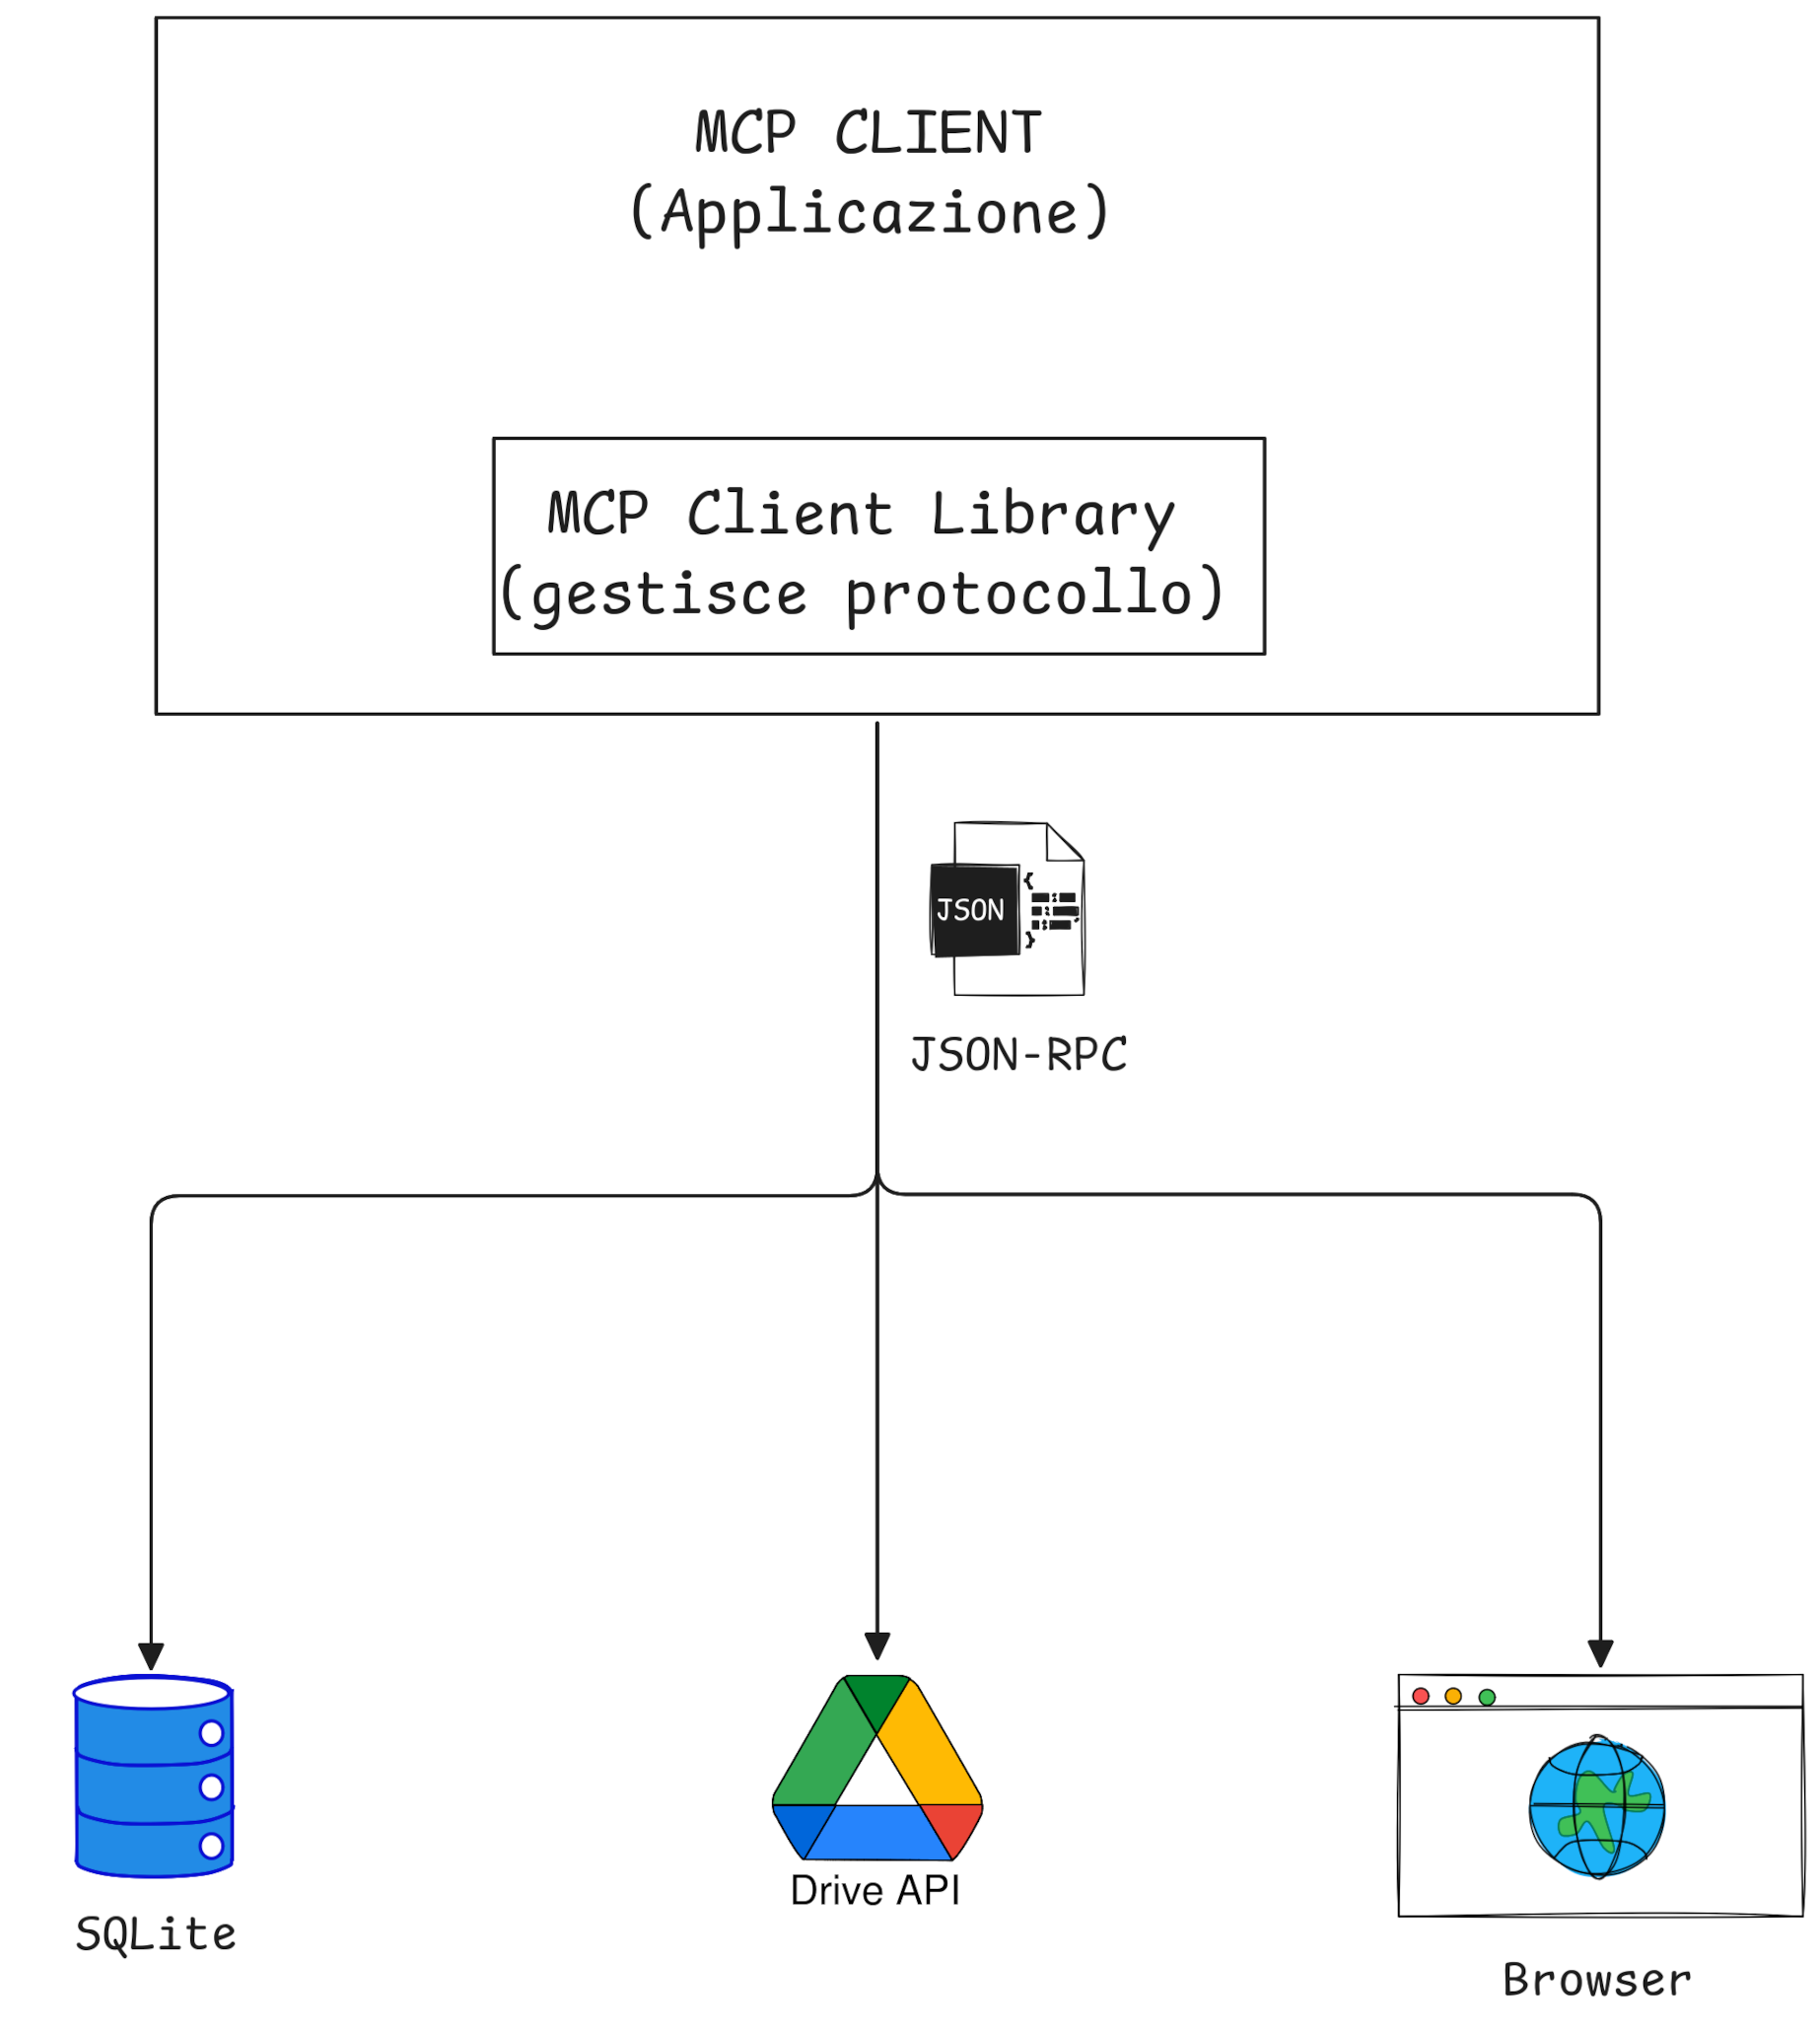

### MCP vs Function Calling Tradizionale

| Aspetto | Function Calling Tradizionale | MCP |
|---------|-------------------------------|-----|
| **Standard** | Ogni piattaforma diversa | Protocollo unico |
| **Portabilità** | Codice specifico per piattaforma | Scrivi una volta, usa ovunque |
| **Risorse** | No supporto nativo | Sì, integrate |
| **Prompts** | No supporto | Sì, template pronti |
| **Discovery** | Manuale | Automatica |
| **Comunicazione** | Varia | JSON-RPC standard |

# 2. MCP con SQLite e Ollama

```bash
pip install "mcp[cli]"
```

> **Nota didattica:** In questa lezione implementiamo manualmente le interfacce MCP (`list_tools`, `call_tool`, `list_resources`, ecc.) per capire come funziona il protocollo dall'interno. Il vero SDK (`mcp>=1.0`) semplifica tutto con decorator:
> ```python
> from mcp.server.fastmcp import FastMCP
> mcp = FastMCP("libreria")
> @mcp.tool()
> def query_database(query: str) -> str: ...
> ```
> La simulazione manuale aiuta a capire cosa il protocollo fa sotto il cofano.

## 2.1 Creazione del Database

In [18]:
import sqlite3
import json
from datetime import datetime
from pathlib import Path

DB_PATH = Path(".") / "db" / "libreria.db"


def init_db():
    # Creazione del database
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    # Evita duplicati: se i dati esistono già, salta l'inserimento
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='autori'")
    if cursor.fetchone():
        cursor.execute("SELECT COUNT(*) FROM autori")
        if cursor.fetchone()[0] > 0:
            print("✓ Database già inizializzato")
            conn.close()
            return

    # Tabella Autori
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS autori (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nome TEXT NOT NULL,
        cognome TEXT NOT NULL,
        nazionalita TEXT,
        anno_nascita INTEGER
    )
    ''')

    # Tabella Libri
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS libri (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        titolo TEXT NOT NULL,
        autore_id INTEGER,
        anno_pubblicazione INTEGER,
        genere TEXT,
        prezzo REAL,
        copie_disponibili INTEGER,
        FOREIGN KEY (autore_id) REFERENCES autori (id)
    )
    ''')

    # Inserimento dati di esempio
    autori = [
        ('Italo', 'Calvino', 'Italiana', 1923),
        ('Umberto', 'Eco', 'Italiana', 1932),
        ('Elena', 'Ferrante', 'Italiana', 1943),
        ('Gabriel', 'García Márquez', 'Colombiana', 1927)
    ]

    cursor.executemany('INSERT INTO autori (nome, cognome, nazionalita, anno_nascita) VALUES (?, ?, ?, ?)', autori)

    libri = [
        ('Il barone rampante', 1, 1957, 'Narrativa', 12.50, 15),
        ('Le città invisibili', 1, 1972, 'Narrativa', 14.00, 8),
        ('Il nome della rosa', 2, 1980, 'Giallo storico', 18.00, 12),
        ('Il pendolo di Foucault', 2, 1988, 'Narrativa', 20.00, 5),
        ("L'amica geniale", 3, 2011, 'Narrativa', 15.00, 20),
        ('Cent\'anni di solitudine', 4, 1967, 'Realismo magico', 16.50, 10),
    ]

    cursor.executemany('INSERT INTO libri (titolo, autore_id, anno_pubblicazione, genere, prezzo, copie_disponibili) VALUES (?, ?, ?, ?, ?, ?)', libri)

    conn.commit()
    print("✓ Database creato con successo!")
    print(f"✓ Inseriti {len(autori)} autori e {len(libri)} libri")

    # Verifichiamo i dati
    cursor.execute('SELECT COUNT(*) FROM autori')
    print(f"✓ Totale autori: {cursor.fetchone()[0]}")

    cursor.execute('SELECT COUNT(*) FROM libri')
    print(f"✓ Totale libri: {cursor.fetchone()[0]}")

    conn.close()



## 2.2 Implementazione del Server MCP

In [19]:
from typing import Any, Dict, List
import json


class SQLiteMCPServer:
    """
    Server MCP che espone un database SQLite.
    Implementa i metodi principali del protocollo MCP.
    """
    
    def __init__(self, db_path: str):
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path)

        # Per avere risultati come dizionari
        self.conn.row_factory = sqlite3.Row  
    
    def get_schema(self) -> Dict[str, Any]:
        """Ottiene lo schema del database"""
        cursor = self.conn.cursor()
        
        # Ottieni tutte le tabelle
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = [row[0] for row in cursor.fetchall()]
        
        schema = {}
        for table in tables:
            cursor.execute(f"PRAGMA table_info({table})")
            columns = [{
                'name': row[1],
                'type': row[2],
                'not_null': bool(row[3]),
                'primary_key': bool(row[5])
            } for row in cursor.fetchall()]
            schema[table] = columns
        
        return schema
    

    # =============
    # RESOURCES
    # =============

    def list_resources(self) -> List[Dict[str, Any]]:
        """
        Elenca le risorse disponibili (metodo MCP).
        In questo caso, esponiamo lo schema del database.
        """
        schema = self.get_schema()
        return [{
            'uri': 'sqlite://libreria/schema',
            'name': 'Database Schema',
            'description': 'Schema completo del database libreria',
            'mimeType': 'application/json'
        }]
    
    def read_resource(self, uri: str) -> Dict[str, Any]:
        """
        Legge una risorsa specifica (metodo MCP).
        """
        if uri == 'sqlite://libreria/schema':
            schema = self.get_schema()
            return {
                'contents': [{
                    'uri': uri,
                    'mimeType': 'application/json',
                    'text': json.dumps(schema, indent=2)
                }]
            }
        else:
            raise ValueError(f"Risorsa non trovata: {uri}")
        
    
    # =============
    # TOOLS
    # =============
    
    def list_tools(self) -> List[Dict[str, Any]]:
        """
        Elenca i tool disponibili (metodo MCP).
        """
        return [
            {
                'name': 'query_database',
                'description': 'Esegue una query SQL SELECT sul database. Restituisce i risultati in formato JSON.',
                'inputSchema': {
                    'type': 'object',
                    'properties': {
                        'query': {
                            'type': 'string',
                            'description': 'Query SQL SELECT da eseguire'
                        }
                    },
                    'required': ['query']
                }
            },
            {
                'name': 'get_table_info',
                'description': 'Ottiene informazioni dettagliate su una tabella specifica',
                'inputSchema': {
                    'type': 'object',
                    'properties': {
                        'table_name': {
                            'type': 'string',
                            'description': 'Nome della tabella'
                        }
                    },
                    'required': ['table_name']
                }
            }
        ]
    
    def call_tool(self, name: str, arguments: Dict[str, Any]) -> Dict[str, Any]:
        """
        Esegue un tool (metodo MCP).
        """
        if name == 'query_database':
            return self._query_database(arguments['query'])
        elif name == 'get_table_info':
            return self._get_table_info(arguments['table_name'])
        else:
            raise ValueError(f"Tool non trovato: {name}")
    
    def _query_database(self, query: str) -> Dict[str, Any]:
        """Esegue una query SQL SELECT"""
        # Verifica di sicurezza: solo SELECT
        if not query.strip().upper().startswith('SELECT'):
            return {
                'content': [{
                    'type': 'text',
                    'text': 'Errore: Solo query SELECT sono permesse per sicurezza'
                }],
                'isError': True
            }
        
        try:
            cursor = self.conn.cursor()
            cursor.execute(query)
            rows = cursor.fetchall()
            
            # Converti i risultati in dizionari
            results = [dict(row) for row in rows]
            
            return {
                'content': [{
                    'type': 'text',
                    'text': json.dumps(results, indent=2, ensure_ascii=False)
                }]
            }
        except Exception as e:
            return {
                'content': [{
                    'type': 'text',
                    'text': f'Errore nell\'esecuzione della query: {str(e)}'
                }],
                'isError': True
            }
    
    def _get_table_info(self, table_name: str) -> Dict[str, Any]:
        """Ottiene informazioni su una tabella"""
        try:
            cursor = self.conn.cursor()
            
            # Schema della tabella
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            
            # Conteggio righe
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            count = cursor.fetchone()[0]
            
            info = {
                'table_name': table_name,
                'row_count': count,
                'columns': [{
                    'name': col[1],
                    'type': col[2],
                    'not_null': bool(col[3]),
                    'primary_key': bool(col[5])
                } for col in columns]
            }
            
            return {
                'content': [{
                    'type': 'text',
                    'text': json.dumps(info, indent=2, ensure_ascii=False)
                }]
            }
        except Exception as e:
            return {
                'content': [{
                    'type': 'text',
                    'text': f'Errore: {str(e)}'
                }],
                'isError': True
            }
    
    def close(self):
        """Chiude la connessione al database"""
        self.conn.close()

## 2.3 Integrazione con Ollama

Creiamo un client che usa Ollama per permettere all'LLM di interagire con il database tramite MCP.

### Come funziona:
1. L'utente fa una domanda in linguaggio naturale
2. L'LLM decide quali tool MCP usare
3. Il client esegue i tool e restituisce i risultati all'LLM
4. L'LLM formula una risposta finale in linguaggio naturale

In [20]:
from ollama import Client


MODEL = 'ministral-3:3b'


PROMPT_TEMPLATE = \
"""You are an assistant that helps users query a library's SQLite database.

DATABASE SCHEMA:
{}

YOU HAVE ACCESS TO THE FOLLOWING TOOLS:
{}

INSTRUCTIONS:
1. When the user asks a question, analyze which tool to use
2. To use a tool, respond EXACTLY in this JSON format:
   {{"tool": "tool_name", "arguments": {{"parameter": "value"}}}}
3. After receiving the tool result, formulate a natural language response
4. If you cannot answer using the available tools, clearly state that

EXAMPLE:
User: "How many books are there?"
You: {{"tool": "query_database", "arguments": {{"query": "SELECT COUNT(*) as total FROM books"}}}}
[receive result]
You: "There are X books in the database."
"""



class MCPClient:
    """
    Client che integra Ollama con il server MCP.
    Permette all'LLM di usare i tool MCP per rispondere alle domande.
    """
    
    def __init__(self, mcp_server):
        self.mcp_server = mcp_server
        self.client =  Client(host='http://localhost:11434')
        self.conversation_history = []
    

    def _create_system_prompt(self) -> str:
        """Crea il prompt di sistema con informazioni sui tool disponibili"""
        tools = self.mcp_server.list_tools()
        schema = self.mcp_server.get_schema()
        

        # Sfrutta la formattazione delle stringhe di python per 
        # completare il template del prompt
        prompt = PROMPT_TEMPLATE.format(
            json.dumps(schema, indent=2, ensure_ascii=False),
            json.dumps([{'name': t['name'], 'description': t['description'], 'parameters': t['inputSchema']['properties']} for t in tools], indent=2, ensure_ascii=False)
        )
        
        return prompt

    def _parse_tool_call(self, response: str) -> tuple:
        """Estrae la chiamata al tool dalla risposta dell'LLM"""
        try:
            # Cerca un oggetto JSON nella risposta
            start = response.find('{')
            end = response.rfind('}') + 1
            
            if start != -1 and end > start:
                json_str = response[start:end]
                tool_call = json.loads(json_str)
                
                if 'tool' in tool_call and 'arguments' in tool_call:
                    return tool_call['tool'], tool_call['arguments']
            
            return None, None
        except:
            return None, None
        

    # CHAT CALL

    def _ollama_chat(self,  messages: list[dict]):
        response = self.client.chat(
            model=MODEL,
             messages=messages
        )
        return response["message"]["content"]
    

    def chat(self, question: str, verbose: bool = True) -> str:
        """
        Fa una domanda e ottiene una risposta usando l'LLM e i tool MCP.
        """
        if verbose:
            print(f"\n{'='*60}")
            print(f"DOMANDA: {question}")
            print(f"{'='*60}")
        

        # FASE 1: L'LLM decide quale tool usare
        messages = [
            {'role': 'system', 'content': self._create_system_prompt()},
            {'role': 'user', 'content': question}
        ]
        
        if verbose:
            print("\n[Fase 1] LLM sta analizzando la domanda...")

        llm_response = self._ollama_chat(messages)


        # FASE 2:  Esecuzione del tool se richiesto
        tool_name, tool_args = self._parse_tool_call(llm_response)

        if tool_name:
            if verbose:
                print(f"\n[Fase 2] Esecuzione del tool: {tool_name}")
                print(f"Argomenti: {json.dumps(tool_args, ensure_ascii=False)}")
            
            tool_result = self.mcp_server.call_tool(tool_name, tool_args)
            result_text = tool_result['content'][0]['text']
            
            if verbose:
                print(f"\n[Risultato del tool]:")
                print(result_text[:500] + ('...' if len(result_text) > 500 else ''))
            
            # FASE 3: L'LLM formula la risposta finale
            if verbose:
                print(f"\n[Fase 3] LLM sta formulando la risposta finale...")
            
            messages.append({'role': 'assistant', 'content': llm_response})
            messages.append({
                'role': 'user',
                'content': f"Risultato del tool {tool_name}:\n{result_text}\n\nOra formula una risposta chiara e concisa alla domanda originale dell'utente."
            })
            
            final_response = self._ollama_chat(messages=messages)
            
            answer = final_response
        else:
            answer = llm_response
        
        if verbose:
            print(f"\n{'='*60}")
            print(f"RISPOSTA FINALE:")
            print(f"{'='*60}")
            print(answer)
            print(f"{'='*60}\n")
        
        return answer


## 2.4 Test

In [21]:
# Inizializzazione database
init_db()

✓ Database già inizializzato


In [22]:
# Creiamo un'istanza del server
mcp_server = SQLiteMCPServer(DB_PATH)

# Testiamo il server
print("=== Risorse disponibili ===")
resources = mcp_server.list_resources()
print(json.dumps(resources, indent=2, ensure_ascii=False))

print("\n=== Tool disponibili ===")
tools = mcp_server.list_tools()
for tool in tools:
    print(f"- {tool['name']}: {tool['description']}")

print("\n=== Schema del database ===")
schema = mcp_server.read_resource('sqlite://libreria/schema')
print(schema['contents'][0]['text'])


=== Risorse disponibili ===
[
  {
    "uri": "sqlite://libreria/schema",
    "name": "Database Schema",
    "description": "Schema completo del database libreria",
    "mimeType": "application/json"
  }
]

=== Tool disponibili ===
- query_database: Esegue una query SQL SELECT sul database. Restituisce i risultati in formato JSON.
- get_table_info: Ottiene informazioni dettagliate su una tabella specifica

=== Schema del database ===
{
  "autori": [
    {
      "name": "id",
      "type": "INTEGER",
      "not_null": false,
      "primary_key": true
    },
    {
      "name": "nome",
      "type": "TEXT",
      "not_null": true,
      "primary_key": false
    },
    {
      "name": "cognome",
      "type": "TEXT",
      "not_null": true,
      "primary_key": false
    },
    {
      "name": "nazionalita",
      "type": "TEXT",
      "not_null": false,
      "primary_key": false
    },
    {
      "name": "anno_nascita",
      "type": "INTEGER",
      "not_null": false,
      "primary_ke

In [23]:
mcp_client = MCPClient(mcp_server)

In [24]:
# Esempio 1: Contare i libri
print(mcp_client.chat("Quanti libri ci sono nel database?"))


DOMANDA: Quanti libri ci sono nel database?

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: query_database
Argomenti: {"query": "SELECT COUNT(*) AS totale_libri FROM libri;"}

[Risultato del tool]:
[
  {
    "totale_libri": 6
  }
]

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
Nel database ci sono **6 libri** registrati.

Nel database ci sono **6 libri** registrati.


In [25]:
# Esempio 2: Trovare libri per autore
print(mcp_client.chat("Quali libri ha scritto Italo Calvino?"))


DOMANDA: Quali libri ha scritto Italo Calvino?

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: query_database
Argomenti: {"query": "SELECT titolo, anno_pubblicazione FROM libri WHERE autore_id IN (SELECT autore_id FROM autori WHERE nome = 'Calvino' AND cognome = 'Italo')"}

[Risultato del tool]:
[]

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
Non ho trovato libri associati all'autore **Italo Calvino** nel database attualmente consultato. Potrebbe trattarsi di un errore di nome o cognome o di un libro non ancora inserito. Se hai bisogno di ulteriori informazioni, posso verificare altre opzioni!

Non ho trovato libri associati all'autore **Italo Calvino** nel database attualmente consultato. Potrebbe trattarsi di un errore di nome o cognome o di un libro non ancora inserito. Se hai bisogno di ulteriori informazioni, posso verificare altre opzioni!


In [26]:
# Esempio 3: Statistiche sui prezzi
print(mcp_client.chat("Qual è il prezzo medio dei libri?"))


DOMANDA: Qual è il prezzo medio dei libri?

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: query_database
Argomenti: {"query": "SELECT AVG(prezzo) AS prezzo_medio FROM libri WHERE prezzo IS NOT NULL;"}

[Risultato del tool]:
[
  {
    "prezzo_medio": 16.0
  }
]

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
Il prezzo medio dei libri nel database è di **16,00 euro**.

Il prezzo medio dei libri nel database è di **16,00 euro**.


In [27]:
# Esempio 4: Libri disponibili per genere
print(mcp_client.chat("Quanti libri di narrativa abbiamo disponibili?"))


DOMANDA: Quanti libri di narrativa abbiamo disponibili?

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: query_database
Argomenti: {"query": "SELECT COUNT(*) AS totale_narrativa FROM libri WHERE genere LIKE '%narrativa%' AND copie_disponibili > 0"}

[Risultato del tool]:
[
  {
    "totale_narrativa": 4
  }
]

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
Nel database ci sono **4 libri di narrativa disponibili** con copie disponibili. Se hai bisogno di dettagli su uno specifico libro, fammi sapere!

Nel database ci sono **4 libri di narrativa disponibili** con copie disponibili. Se hai bisogno di dettagli su uno specifico libro, fammi sapere!


In [28]:
# Esempio 5: Query complessa
print(mcp_client.chat("Mostrami i 3 libri più costosi con il nome dell'autore"))


DOMANDA: Mostrami i 3 libri più costosi con il nome dell'autore

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: query_database
Argomenti: {"query": "SELECT l.titolo, a.nome AS autore_nome, a.cognome AS autore_cognome, l.prezzo FROM libri l JOIN autori a ON l.autore_id = a.id ORDER BY l.prezzo DESC LIMIT 3;"}

[Risultato del tool]:
[
  {
    "titolo": "Il pendolo di Foucault",
    "autore_nome": "Umberto",
    "autore_cognome": "Eco",
    "prezzo": 20.0
  },
  {
    "titolo": "Il nome della rosa",
    "autore_nome": "Umberto",
    "autore_cognome": "Eco",
    "prezzo": 18.0
  },
  {
    "titolo": "Cent'anni di solitudine",
    "autore_nome": "Gabriel",
    "autore_cognome": "García Márquez",
    "prezzo": 16.5
  }
]

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
I tre libri più costosi presenti nel database sono:

1. **"Il pendolo di Foucault"** di Umberto Eco (prezzo: 20,00 €)
2. **"Il nome della rosa"** di Umberto Eco (prezzo: 18,00 €)

In [29]:
# Esempio 6: Informazioni su una tabella
print(mcp_client.chat("Dammi informazioni sulla tabella autori"))



DOMANDA: Dammi informazioni sulla tabella autori

[Fase 1] LLM sta analizzando la domanda...

[Fase 2] Esecuzione del tool: get_table_info
Argomenti: {"table_name": "autori"}

[Risultato del tool]:
{
  "table_name": "autori",
  "row_count": 4,
  "columns": [
    {
      "name": "id",
      "type": "INTEGER",
      "not_null": false,
      "primary_key": true
    },
    {
      "name": "nome",
      "type": "TEXT",
      "not_null": true,
      "primary_key": false
    },
    {
      "name": "cognome",
      "type": "TEXT",
      "not_null": true,
      "primary_key": false
    },
    {
      "name": "nazionalita",
      "type": "TEXT",
      "not_null": false,
      "primary_key": false
  ...

[Fase 3] LLM sta formulando la risposta finale...

RISPOSTA FINALE:
La tabella **autori** contiene le seguenti informazioni su ogni autore:

- **ID** (intero, chiave primaria): Identificatore univoco dell'autore.
- **Nome** (testo, non null): Nome dell'autore.
- **Cognome** (testo, non null): Co

In [30]:
# Chiudi la connessione al database
mcp_server.close()
print("✓ Connessioni chiuse correttamente")

✓ Connessioni chiuse correttamente


# 3. Server MCP con FastMCP (SDK Ufficiale)

La sezione 2 ha implementato le interfacce MCP manualmente per capire il protocollo. Nella pratica si usa l'SDK ufficiale `mcp`, che riduce un server completo a poche righe grazie ai decorator.

### FastMCP

`FastMCP` è la classe principale dell'SDK. Ogni tool è una normale funzione Python decorata con `@mcp.tool()` — il framework genera automaticamente lo schema JSON dal docstring e dai type hint. Le **Resources** si definiscono con `@mcp.resource("uri")`.

Il server viene avviato come processo separato e comunica tramite **stdio** (JSON-RPC): non gira dentro il notebook, va lanciato con `python libreria_server.py`.

In [ ]:
%%writefile libreria_server.py
import sqlite3
import json
from pathlib import Path
from mcp.server.fastmcp import FastMCP

DB_PATH = Path(__file__).parent / "db" / "libreria.db"
mcp = FastMCP("libreria")


@mcp.tool()
def query_database(query: str) -> str:
    """Esegue una query SQL SELECT sul database libreria. Restituisce i risultati in JSON."""
    if not query.strip().upper().startswith("SELECT"):
        return "Errore: solo query SELECT sono permesse"
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        cursor.execute(query)
        rows = [dict(row) for row in cursor.fetchall()]
        conn.close()
        return json.dumps(rows, indent=2, ensure_ascii=False)
    except Exception as e:
        return f"Errore: {e}"


@mcp.tool()
def get_table_info(table_name: str) -> str:
    """Ottiene schema e numero di righe di una tabella del database."""
    try:
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        cursor.execute(f"PRAGMA table_info({table_name})")
        columns = [{"name": r[1], "type": r[2], "not_null": bool(r[3])} for r in cursor.fetchall()]
        cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
        count = cursor.fetchone()[0]
        conn.close()
        return json.dumps({"table": table_name, "rows": count, "columns": columns}, indent=2, ensure_ascii=False)
    except Exception as e:
        return f"Errore: {e}"


@mcp.resource("sqlite://libreria/schema")
def get_schema() -> str:
    """Schema completo del database libreria in formato JSON."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [r[0] for r in cursor.fetchall()]
    schema = {}
    for t in tables:
        cursor.execute(f"PRAGMA table_info({t})")
        schema[t] = [{"name": r[1], "type": r[2]} for r in cursor.fetchall()]
    conn.close()
    return json.dumps(schema, indent=2, ensure_ascii=False)


if __name__ == "__main__":
    mcp.run(transport="stdio")


## 3.1 Client MCP

Il client MCP si connette al server tramite stdio e può scoprire e invocare qualsiasi tool esposto.
La comunicazione è asincrona — nelle celle Jupyter si usa `await` direttamente.

In [ ]:
import asyncio
import json
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

SERVER_SCRIPT = str(Path(".") / "libreria_server.py")

async def demo_mcp_client():
    server_params = StdioServerParameters(
        command="python",
        args=[SERVER_SCRIPT]
    )

    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            # Scopri tools disponibili
            tools_result = await session.list_tools()
            print("=== Tools disponibili ===")
            for tool in tools_result.tools:
                print(f"  - {tool.name}: {tool.description[:70]}")

            # Scopri resources disponibili
            resources_result = await session.list_resources()
            print("\n=== Resources disponibili ===")
            for res in resources_result.resources:
                print(f"  - {res.uri}: {res.description}")

            # Chiama un tool
            print("\n=== Tool: libri più costosi ===")
            result = await session.call_tool(
                "query_database",
                {"query": "SELECT titolo, prezzo FROM libri ORDER BY prezzo DESC LIMIT 3"}
            )
            print(result.content[0].text)

            # Leggi una resource
            print("\n=== Resource: schema database ===")
            resource = await session.read_resource("sqlite://libreria/schema")
            schema = json.loads(resource.contents[0].text)
            for table, cols in schema.items():
                print(f"  {table}: {[c['name'] for c in cols]}")


await demo_mcp_client()


# 4. mcp-server-sqlite: un Server MCP Esistente

Il server SQLite ufficiale di Anthropic è archiviato, ma esiste [`mcp-server-sqlite`](https://pypi.org/project/mcp-server-sqlite/) su PyPI — un server MCP pronto all'uso che espone qualsiasi database SQLite con tools, resources e un prompt integrato.

```bash
pip install mcp-server-sqlite
```

Questo è il modello tipico di MCP nella pratica: un server scritto da qualcun altro viene integrato in qualsiasi applicazione AI compatibile senza modifiche. Il client non sa né gli importa come è implementato il server.

### Tools esposti da mcp-server-sqlite
| Tool | Descrizione |
|------|-------------|
| `list_tables` | Elenca le tabelle del database |
| `describe_table` | Schema di una tabella |
| `read_query` | Esegue query SELECT |
| `write_query` | Esegue INSERT / UPDATE / DELETE |
| `create_table` | Crea nuove tabelle |

In [ ]:
async def demo_mcp_server_sqlite():
    server_params = StdioServerParameters(
        command="mcp-server-sqlite",
        args=["--db-path", str(DB_PATH)]
    )

    async with stdio_client(server_params) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            # Lista tools disponibili
            tools = await session.list_tools()
            print("=== Tools di mcp-server-sqlite ===")
            for tool in tools.tools:
                print(f"  - {tool.name}")

            # Lista tabelle
            print("\n=== Tabelle nel database ===")
            result = await session.call_tool("list_tables", {})
            print(result.content[0].text)

            # Descrizione tabella
            print("\n=== Schema tabella 'libri' ===")
            result = await session.call_tool("describe_table", {"table_name": "libri"})
            print(result.content[0].text)

            # Query con JOIN
            print("\n=== Libri più costosi con autore ===")
            result = await session.call_tool(
                "read_query",
                {"query": "SELECT l.titolo, a.cognome, l.prezzo FROM libri l JOIN autori a ON l.autore_id = a.id ORDER BY l.prezzo DESC LIMIT 3"}
            )
            print(result.content[0].text)


await demo_mcp_server_sqlite()
